In [1]:
import torch
import numpy as np
import os
import sys

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *
%matplotlib widget

In [2]:
SETTINGS = {"epoch": 0, "n": 100, "split":"test" }

CAT_NAMES = {0: 'Diamant', 1: 'Oeuf', 2: 'Triangle'}   # adaptez
 
CONDITIONS = [
    "3mod_basic_s126_a01",
    "3mod_basic_s126_a02",
    "3mod_basic_s126_a03",

]

df = run_conditions(CONDITIONS, plot=False)


── Condition : 3mod_basic_s126_a01 ──


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/home/luc

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_a01_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_a01_biased_00/checkpoints/last.ckpt


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


LDA = 94.00%

── Condition : 3mod_basic_s126_a02 ──
Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_a02_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_a02_biased_00/checkpoints/last.ckpt


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/home/luc

LDA = 95.00%

── Condition : 3mod_basic_s126_a03 ──
Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_a03_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_a03_biased_00/checkpoints/last.ckpt
LDA = 98.00%


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [3]:
def plot_lda_f(df):
    df = df.copy()
    df["alpha"] = df.index.str.extract(r'a(\d+)$', expand=False).astype(int) / 10
    df = df.sort_values("alpha")

    color_lda   = "#0a304a"
    color_chance = "#cc3333"

    xticks = np.arange(0, 2.1, 0.1)
    col   = color_lda
    ydata = df["lda_score"]
    label = "LDA"

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df["alpha"], ydata,
                linestyle="-", linewidth=2, color=col, label=label)

    ax.axhline(y=0.33, color=color_chance, linewidth=1.5,
                linestyle='--', label="Chance level (0.33)")

    ax.set_xlabel("α")
    ax.set_ylabel(label, color=col)
    ax.tick_params(axis='y', labelcolor=col)
    ax.set_xticks(xticks)
    ax.set_xlim(0, 2)
    plt.xticks(rotation=45)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.title(f"{label} evolution with α")

    plt.tight_layout()
    plt.show()

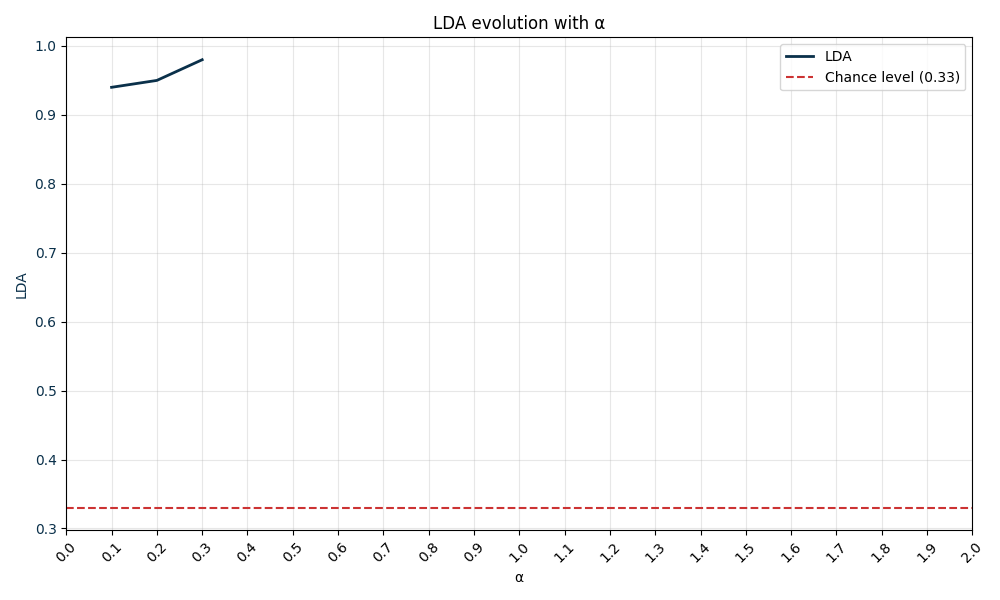

In [4]:
plot_lda_f(df)